In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from torchvision import models
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# === CONFIGURATION ===
class Config:
    OUTPUT_DIR = 'working'
    BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pt")

config = Config()

# === DATASET ===
class MelSpectrogramDataset(Dataset):
    def __init__(self, data_dict, label_dict):
        self.samples = list(data_dict.keys())
        self.data_dict = data_dict
        self.label_dict = label_dict

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        samplename = self.samples[idx]
        mel = self.data_dict[samplename]
        label = self.label_dict[samplename]
        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return mel_tensor, label_tensor
    

# === Data loaders ===

def load_file(file):
    samplename = file.stem
    species_id = samplename.split("-")[0]
    mel_spec = np.load(file)
    return samplename, mel_spec, species_id

def load_data_structure_parallel(root_dir, max_workers=8):
    loaded_data = {}
    sample_to_label = {}

    files = [file for class_dir in Path(root_dir).iterdir() if class_dir.is_dir()
             for file in class_dir.glob("*.npy")]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_file = {executor.submit(load_file, file): file for file in files}
        for future in as_completed(future_to_file):
            samplename, mel_spec, species_id = future.result()
            loaded_data[samplename] = mel_spec
            sample_to_label[samplename] = species_id

    return loaded_data, sample_to_label

def prepare_dataloaders(data_dict, label_dict, batch_size, train_names=None, val_names=None, label_encoder=None):
    sample_names = sorted(label_dict.keys())

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(list(label_dict.values()))

    # Map sample_name -> encoded label correctly
    sample_to_encoded = {
        sample_name: label_encoder.transform([label_dict[sample_name]])[0]
        for sample_name in sample_names
    }

    # Use saved train/val names if provided
    if train_names is None or val_names is None:
        train_names, val_names = train_test_split(sample_names, test_size=0.2, random_state=42)

    train_data = {k: data_dict[k] for k in train_names}
    val_data = {k: data_dict[k] for k in val_names}
    train_labels = {k: sample_to_encoded[k] for k in train_names}
    val_labels = {k: sample_to_encoded[k] for k in val_names}

    train_ds = MelSpectrogramDataset(train_data, train_labels)
    val_ds = MelSpectrogramDataset(val_data, val_labels)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size)

    return train_dl, val_dl, len(label_encoder.classes_), label_encoder




# === MODEL ===
class MelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

class MelResNetInference(nn.Module):
    def __init__(self, num_classes, backbone_name="resnet18"):
        super().__init__()
        
        # Choose backbone based on the name (no pretrained weights)
        if backbone_name == "resnet18":
            self.backbone = models.resnet18(weights=None)
        elif backbone_name == "resnet34":
            self.backbone = models.resnet34(weights=None)
        elif backbone_name == "resnet50":
            self.backbone = models.resnet50(weights=None)
        elif backbone_name == "resnet101":
            self.backbone = models.resnet101(weights=None)
        elif backbone_name == "resnet152":
            self.backbone = models.resnet152(weights=None)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")
        
        # Adjust the first conv layer for 1-channel input
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        # Replace the final fully connected layer
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            return torch.argmax(logits, dim=1)

    @classmethod
    def load_from_checkpoint(cls, checkpoint_path, num_classes, backbone_name="resnet18"):
        model = cls(num_classes, backbone_name=backbone_name)
        model.load_state_dict(torch.load(checkpoint_path, map_location="cpu"))
        model.eval()
        return model

# === EVALUATION ===
def evaluate_roc_auc(model, dataloader, device, num_classes):
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    y_true = label_binarize(all_targets, classes=np.arange(num_classes))
    scored_classes = np.where(y_true.sum(axis=0) > 0)[0]

    if len(scored_classes) == 0:
        return 0.0

    try:
        return roc_auc_score(y_true[:, scored_classes], all_probs[:, scored_classes], average="macro")
    except ValueError:
        return 0.0
    
# Calculate accuracies
def evaluate_accuracy(model, val_dl, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_dl:
            inputs, labels = batch
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    acc = accuracy_score(all_labels.numpy(), all_preds.numpy())
    return acc

def evaluate_f1(model, dataloader, device):
    """
    Returns (macro_f1, weighted_f1) scores.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model.predict(x)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    return macro_f1, weighted_f1


# This loads all the mel_spectrograms at once into memery need atleast 12 GB RAM

In [3]:
ROOT_DIR = Path(config.OUTPUT_DIR) / "mel_spectrograms"
loaded_bird_data, sample_to_label = load_data_structure_parallel(ROOT_DIR)

# Load saved splits
train_names = np.load(os.path.join(config.OUTPUT_DIR, "train_names.npy"), allow_pickle=True).tolist()
val_names = np.load(os.path.join(config.OUTPUT_DIR, "val_names.npy"), allow_pickle=True).tolist()

# Load label encoder
label_encoder = joblib.load(os.path.join(config.OUTPUT_DIR, "label_encoder.pkl"))
print("✅ Loaded LabelEncoder.")

# Pass them in
train_dl, val_dl, num_classes, label_encoder = prepare_dataloaders(
    loaded_bird_data, sample_to_label, batch_size=32, 
    train_names=train_names, val_names=val_names, label_encoder=label_encoder
)

✅ Loaded LabelEncoder.


In [4]:
def load_and_compare_val_dl(val_dl, save_dir):
    load_path = os.path.join(save_dir, "val_dl_full.npz")
    data = np.load(load_path, allow_pickle=True)
    
    saved_sample_names = data['sample_names'].tolist()
    saved_labels = data['labels']

    current_sample_names = val_dl.dataset.samples
    current_labels = np.array([label.item() for _, label in val_dl.dataset])

    # Compare sample names
    if saved_sample_names != current_sample_names:
        print("❌ Sample names mismatch!")
    else:
        print("✅ Sample names match.")

    # Compare labels
    if not np.array_equal(saved_labels, current_labels):
        print("❌ Labels mismatch!")
    else:
        print("✅ Labels match.")


load_and_compare_val_dl(val_dl, config.OUTPUT_DIR)


✅ Sample names match.
✅ Labels match.


# Loads models and gets ROC-AUC score for each

In [5]:
# # Paths to your saved best models
# checkpoint_paths = {
#     "resnet18": "working/best_model_res18_label_fix.pt",
#     "resnet50": "working/best_model_res50_label_fix.pt",
#     "resnet101": "working/best_model_res101_label_fix.pt",
#     "alexnet": "working/best_model_alex1_label_fix.pt",
# }

# # Device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Load models properly
# model_res18_load = MelResNetInference.load_from_checkpoint(
#     checkpoint_path=checkpoint_paths["resnet18"],
#     num_classes=num_classes,
#     backbone_name="resnet18"
# )

# model_res50_load = MelResNetInference.load_from_checkpoint(
#     checkpoint_path=checkpoint_paths["resnet50"],
#     num_classes=num_classes,
#     backbone_name="resnet50"
# )

# model_res101_load = MelResNetInference.load_from_checkpoint(
#     checkpoint_path=checkpoint_paths["resnet101"],
#     num_classes=num_classes,
#     backbone_name="resnet101"
# )

# # AlexNet-style CNN loading (separate because it’s not ResNet)
# model_alex_1_load = MelCNN(num_classes)
# model_alex_1_load.load_state_dict(torch.load(checkpoint_paths["alexnet"], map_location="cpu"))
# model_alex_1_load.eval()

# # Move models to device
# model_res18_load = model_res18_load.to(device)
# model_res50_load = model_res50_load.to(device)
# model_res101_load = model_res101_load.to(device)
# model_alex_1_load = model_alex_1_load.to(device)
import torch

# Paths to your saved best models
checkpoint_paths = {
    "resnet18": "working/best_model_res18_20_ep.pt",
    "resnet50": "working/best_model_res50_20_ep.pt",
    "resnet101": "working/best_model_res101_20_ep.pt",
    "alexnet": "working/best_model_alex1_20_ep.pt",
    # New ones you trained:
    "resnet18_focal": "working/best_model_res18_focal_not_weighted.pt",
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models properly
model_res18_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18"],
    num_classes=num_classes,
    backbone_name="resnet18"
)

model_res50_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet50"],
    num_classes=num_classes,
    backbone_name="resnet50"
)

model_res101_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet101"],
    num_classes=num_classes,
    backbone_name="resnet101"
)

# AlexNet-style CNN loading (separate because it’s not ResNet)
model_alex_1_load = MelCNN(num_classes)
model_alex_1_load.load_state_dict(torch.load(checkpoint_paths["alexnet"], map_location="cpu"))
model_alex_1_load.eval()

model_res18_focal_load = MelResNetInference.load_from_checkpoint(
    checkpoint_path=checkpoint_paths["resnet18_focal"],
    num_classes=num_classes,
    backbone_name="resnet18"
)


# Move all models to device
model_res18_load = model_res18_load.to(device)
model_res50_load = model_res50_load.to(device)
model_res101_load = model_res101_load.to(device)
model_alex_1_load = model_alex_1_load.to(device)
model_res18_focal_load = model_res18_focal_load.to(device)


# Eval

In [6]:
# Group models
models = {
    "ResNet50": model_res50_load,
    "ResNet101": model_res101_load,
    "AlexNet": model_alex_1_load,
    "ResNet18 (CrossEntropy)": model_res18_load,
    "ResNet18 (Focal loss)": model_res18_focal_load,
}


# Collect results into a list
results = []

print("Model Validation Metrics (ROC AUC, Accuracy, F1 Macro, F1 Weighted):")
for model_name, model in models.items():
    roc_auc = evaluate_roc_auc(model, val_dl, device, num_classes)
    acc = evaluate_accuracy(model, val_dl, device)
    macro_f1, weighted_f1 = evaluate_f1(model, val_dl, device)
    
    results.append({
        "Model": model_name,
        "ROC AUC": roc_auc,
        "Accuracy": acc,
        "F1 Macro": macro_f1,
        "F1 Weighted": weighted_f1
    })
    
    print(f"{model_name}: ROC AUC = {roc_auc:.4f} | Accuracy = {acc:.4f} | F1 Macro = {macro_f1:.4f} | F1 Weighted = {weighted_f1:.4f}")

# Create DataFrame
results_df = pd.DataFrame(results)


Model Validation Metrics (ROC AUC, Accuracy, F1 Macro, F1 Weighted):
ResNet50: ROC AUC = 0.9739 | Accuracy = 0.6475 | F1 Macro = 0.4383 | F1 Weighted = 0.6363
ResNet101: ROC AUC = 0.9743 | Accuracy = 0.7096 | F1 Macro = 0.5604 | F1 Weighted = 0.7033
AlexNet: ROC AUC = 0.9534 | Accuracy = 0.5160 | F1 Macro = 0.3736 | F1 Weighted = 0.5141
ResNet18 (CrossEntropy): ROC AUC = 0.9802 | Accuracy = 0.7203 | F1 Macro = 0.5822 | F1 Weighted = 0.7126
ResNet18 (Focal loss): ROC AUC = 0.9721 | Accuracy = 0.7108 | F1 Macro = 0.5818 | F1 Weighted = 0.7051


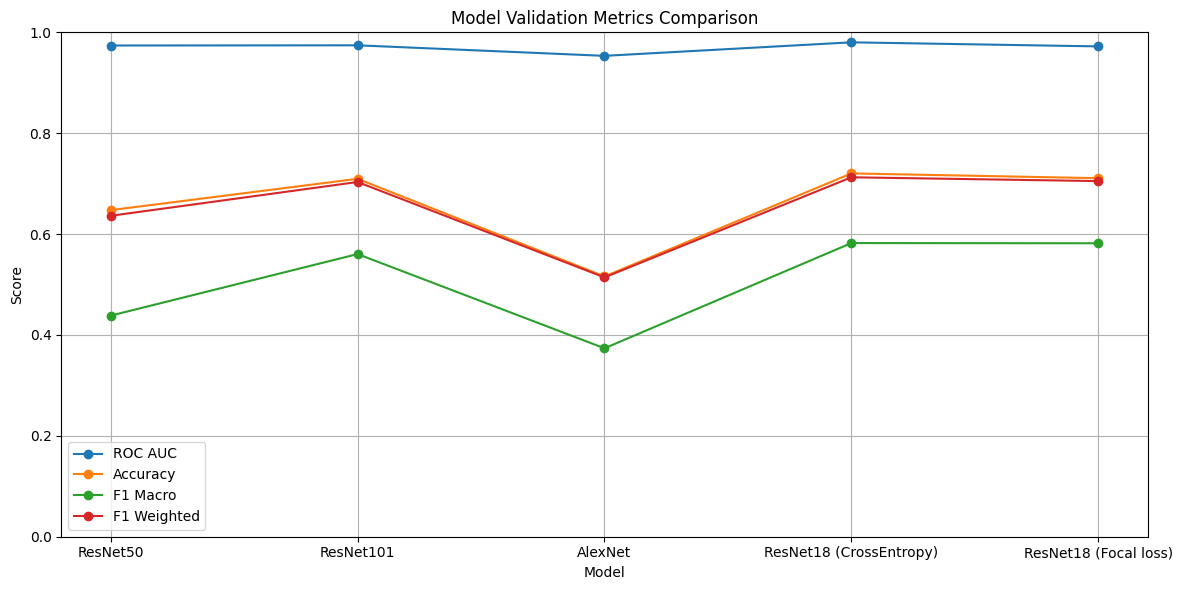

In [7]:
# Plot
metrics = ["ROC AUC", "Accuracy", "F1 Macro", "F1 Weighted"]
fig, ax = plt.subplots(figsize=(12, 6))

for metric in metrics:
    ax.plot(results_df["Model"], results_df[metric], marker="o", label=metric)

ax.set_title("Model Validation Metrics Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0.0, 1.0)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

def plot_confusion_matrix_top_classes(
    model, val_dl, num_classes, device, label_encoder=None, 
    top_n=5, bottom_n=None, show_labels=True
):
    """
    Predicts on val_dl, builds confusion matrix, and plots top-N or bottom-N classes based on frequency.

    Args:
        model: Trained PyTorch model.
        val_dl: Validation DataLoader.
        num_classes: Total number of classes.
        device: Torch device ("cpu" or "cuda").
        label_encoder: LabelEncoder instance (optional).
        top_n: Number of most common classes to visualize (if bottom_n is None).
        bottom_n: Number of least common classes to visualize (overrides top_n if given).
        show_labels: Whether to show axis labels and numbers in the heatmap.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for mel_batch, label_batch in val_dl:
            mel_batch = mel_batch.to(device)
            preds = model.predict(mel_batch)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(label_batch.numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Build confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    # Normalize confusion matrix
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-6)

    # Select classes based on top_n or bottom_n
    class_counts = np.bincount(all_labels, minlength=num_classes)
    valid_classes = np.where(class_counts > 0)[0]

    if bottom_n is not None:
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[:bottom_n]]
        title_suffix = f"Bottom {bottom_n} Classes (with at least 1 sample)"
    else:
        sorted_valid = np.argsort(class_counts[valid_classes])
        selected_classes = valid_classes[sorted_valid[-top_n:]]
        title_suffix = f"Top {top_n} Classes"

    cm_selected = cm_norm[np.ix_(selected_classes, selected_classes)]

    if label_encoder is not None:
        selected_class_labels = [label_encoder.inverse_transform([i])[0] for i in selected_classes]
    else:
        selected_class_labels = [str(i) for i in selected_classes]

    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_selected, 
        annot=show_labels,  # ✅ NOW this respects the flag
        fmt=".2f",
        cmap="Blues",
        xticklabels=selected_class_labels if show_labels else False,
        yticklabels=selected_class_labels if show_labels else False
    )
    plt.xlabel("Predicted Label" if show_labels else "")
    plt.ylabel("True Label" if show_labels else "")
    plt.title(f"Normalized Confusion Matrix ({title_suffix})")
    plt.tight_layout()
    plt.show()


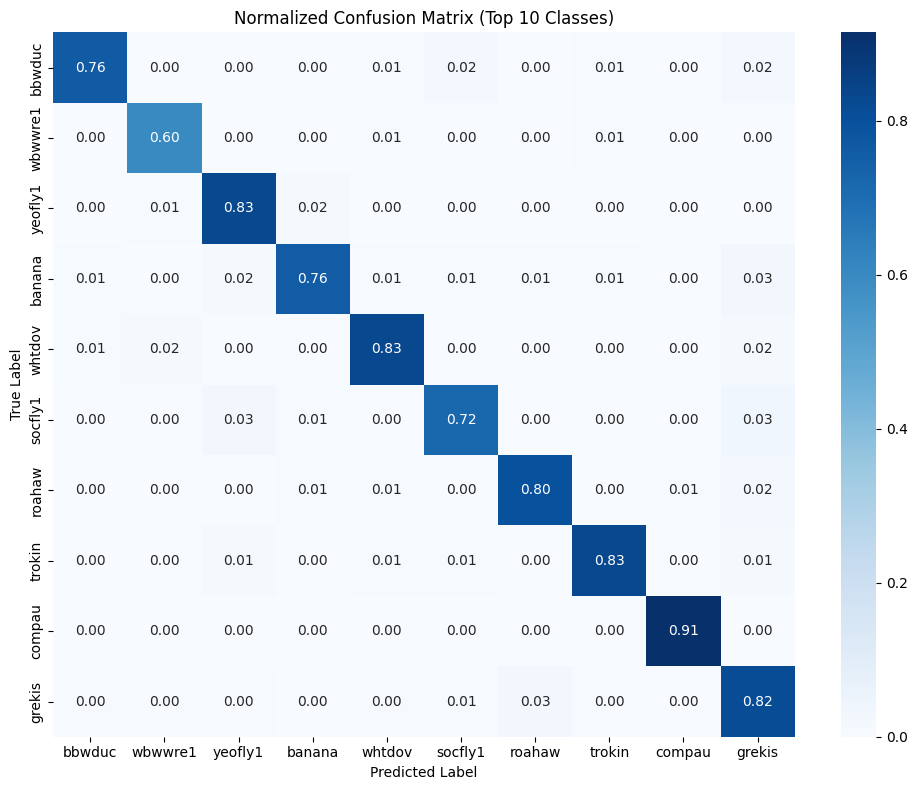

In [9]:
plot_confusion_matrix_top_classes(
    model_res18_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    top_n=10, 
    show_labels=True 
)

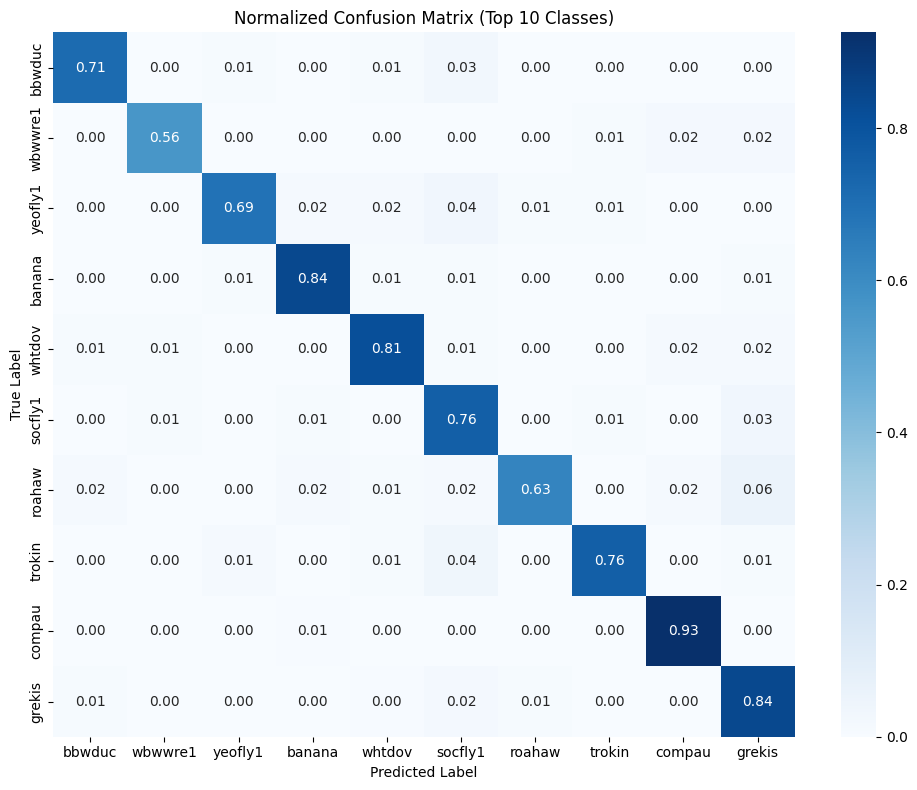

In [ ]:
plot_confusion_matrix_top_classes(
    model_res50_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    top_n=10, 
    show_labels=True  
)

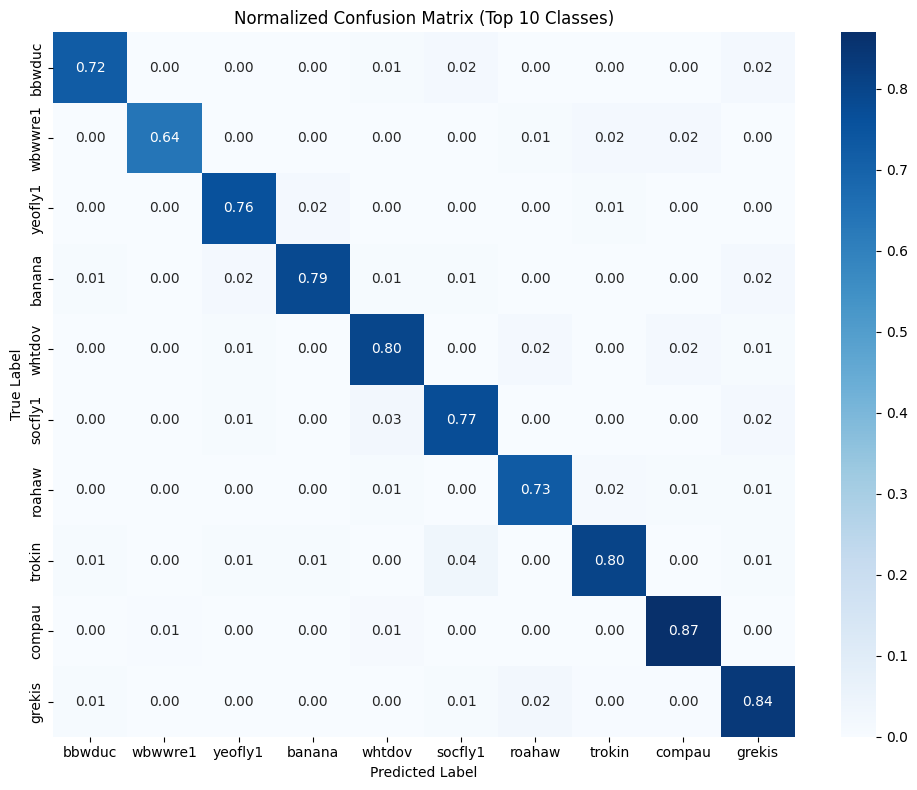

In [11]:
plot_confusion_matrix_top_classes(
    model_res101_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    top_n=10, 
    show_labels=True
)

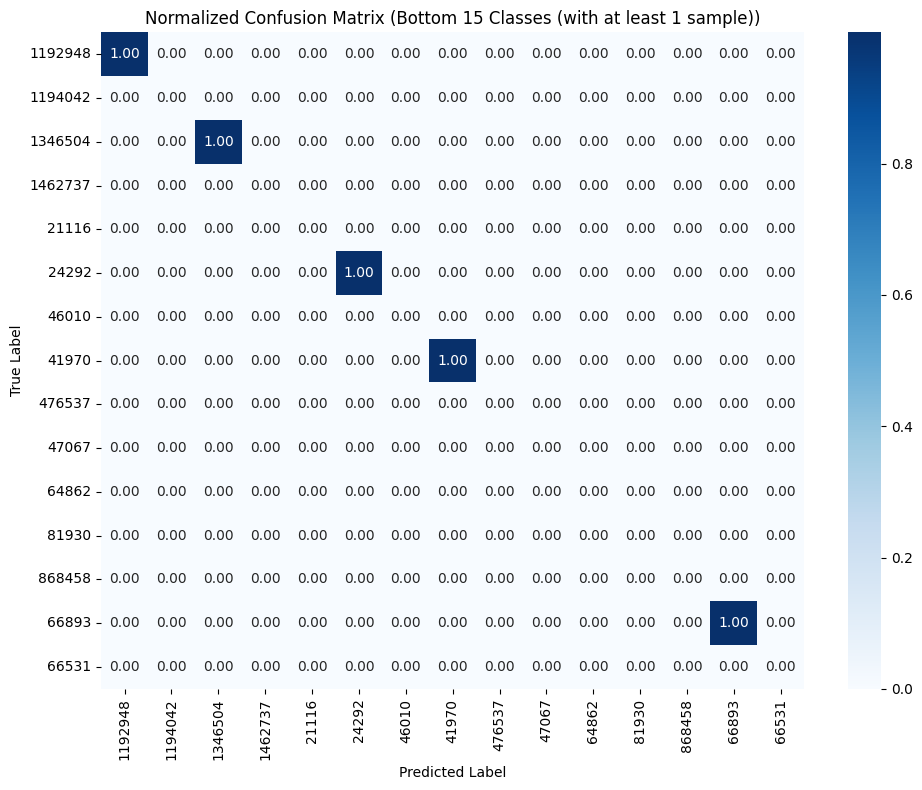

In [12]:
plot_confusion_matrix_top_classes(
    model_res18_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    bottom_n=15, 
    show_labels=True  # ❌ No labels (too many classes)
)

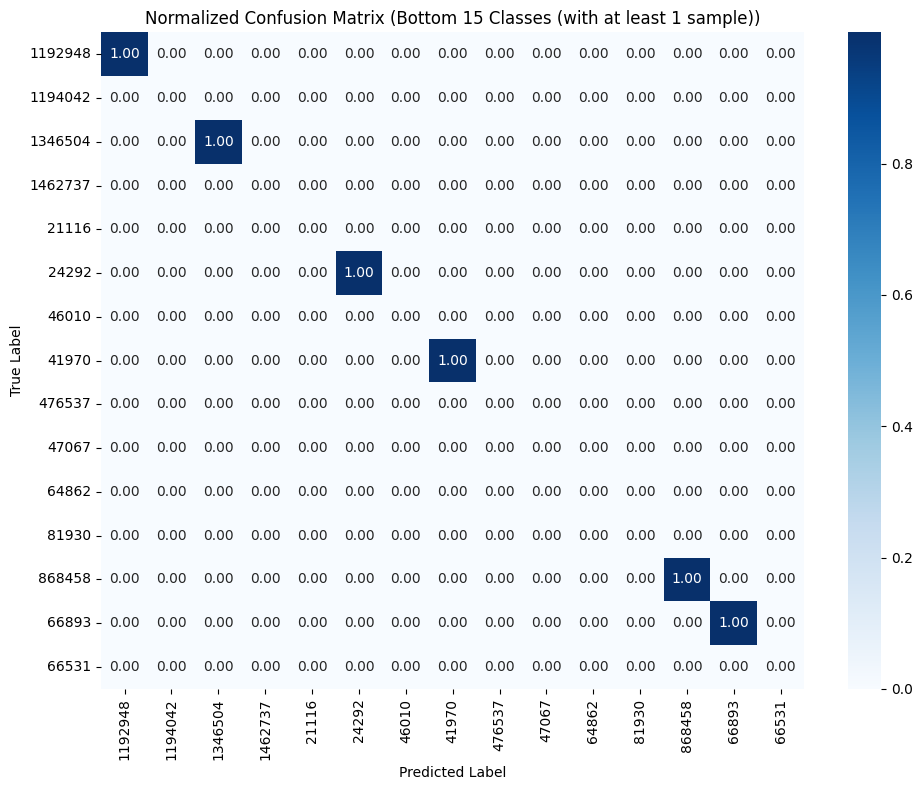

In [15]:
plot_confusion_matrix_top_classes(
    model_res101_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    bottom_n=15, 
    show_labels=True  # ❌ No labels (too many classes)
)

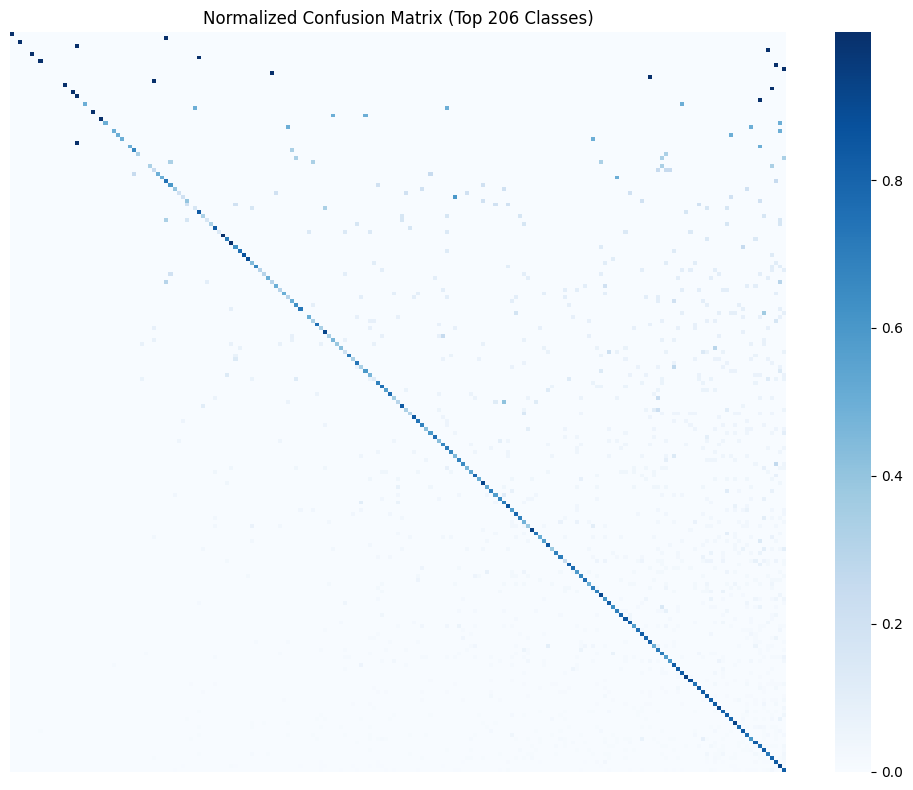

In [16]:
plot_confusion_matrix_top_classes(
    model_res18_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    top_n=206, 
    show_labels=False  # ❌ No labels (too many classes)
)

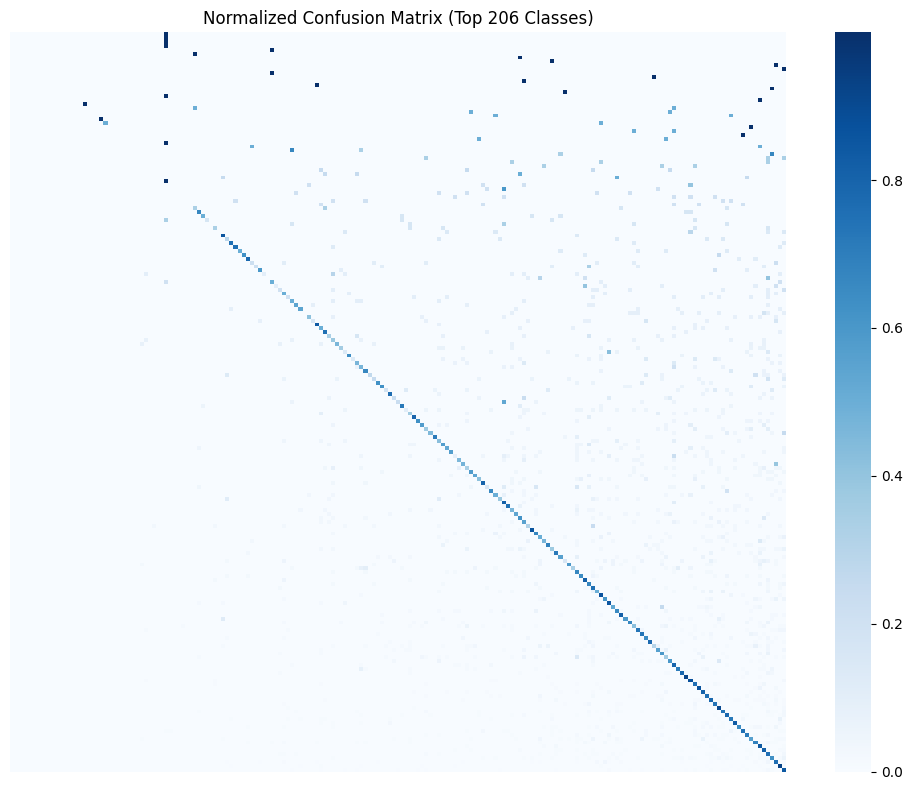

In [17]:
plot_confusion_matrix_top_classes(
    model_res50_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    top_n=206, 
    show_labels=False  # ❌ No labels (too many classes)
)

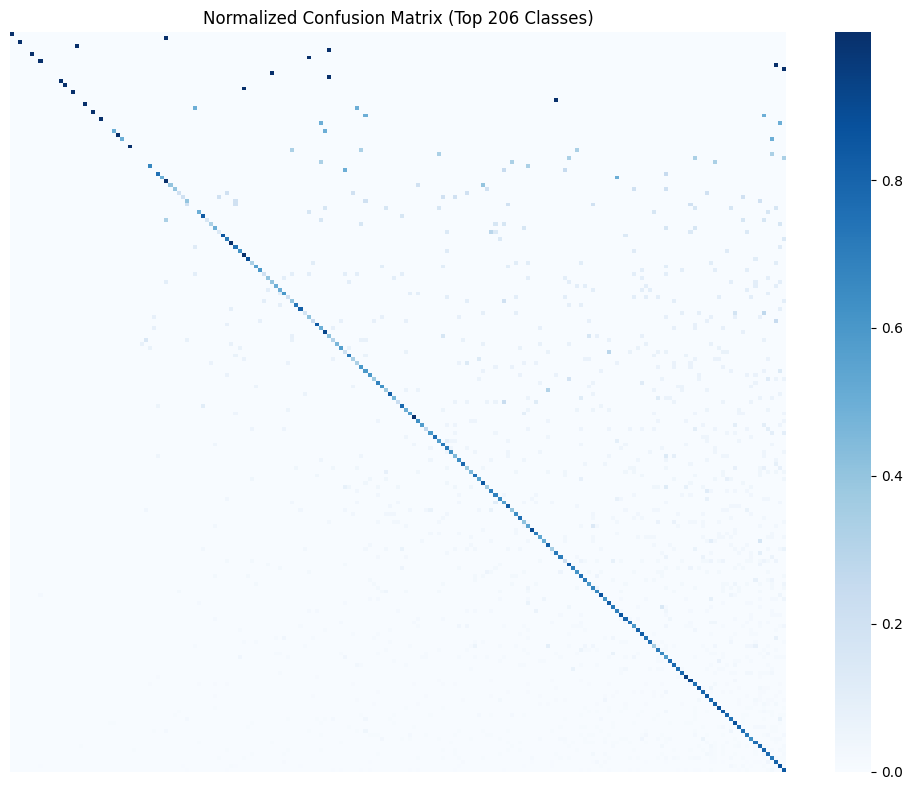

In [18]:
plot_confusion_matrix_top_classes(
    model_res101_load, 
    val_dl, 
    num_classes, 
    device, 
    label_encoder=label_encoder, 
    top_n=206, 
    show_labels=False  # ❌ No labels (too many classes)
)